*Developed by Emille Ishida (LPCA), May/2026 for the [in2p3 School of Statistics](https://indico.in2p3.fr/event/37891/)*  
*Original data from the [PLAsTiCC Kaggle data challenge](https://www.kaggle.com/c/PLAsTiCC-2018)*  
*Analysis taken from the [SNAD tutorials](https://coniferest.snad.space/en/latest/notebooks.html)*

In order to run this notebook you will need to install 2 extra packages:

`pip install coniferest`  
`pip install datasets`

# Fink

The original data set is composed by astronomical time-series observed in 6 different broad-band filters. 
Each multi-dimensional time-series is called a *light curve*.   
They represent the variation of brightness of a given astronomical source as a function of time and wavelength.

In this notebook, we will consider only events of the [supernova class](https://www.youtube.com/watch?v=-IjAwszbiO8), which correspond to the final cataclysmic event marking the end of life of massive stars or binary stellar systems. 

## The shape of the time-series and their astrophysical source

The figure below ([Kessler *et al.*, 2019](https://arxiv.org/pdf/1903.11756), figure 1), shows the different type of behaviors which can be associated to different astrophysical origins (right vertical axis).




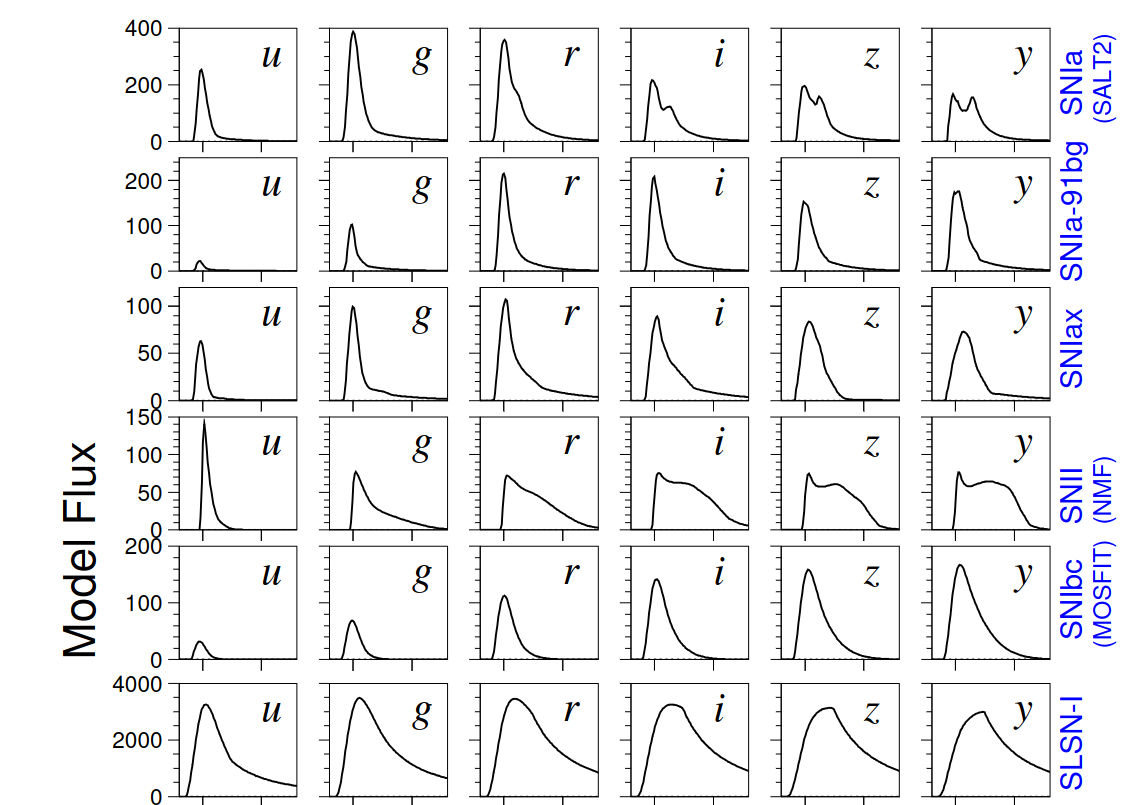

The continuous nature of the curves in the figure above does not depict the innhomogeneous sampling resulting from the telescope pointing strategy. In reality, the data will look more like the image below ([Kessler et al., 2019](https://arxiv.org/pdf/1903.11756), figure 16)

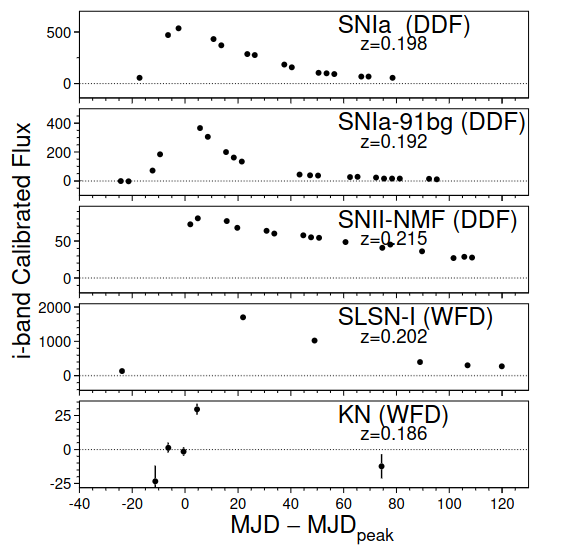

## Featurization

In order to use this data in a traditional machine learning scenario, it is necessary to transform each light curve in a set of features with fix dimensionality.  

In this notebook, we will use the as pre-processed by the SNAD team ([Ishida et al., 2021](https://www.aanda.org/articles/aa/pdf/2021/06/aa37709-20.pdf)). This includes:

- consider only SN-classes
- use only filters *g, r* and *i*
- only use observations between -20 and +100 days since maximum brightness in *r*-band
- fit each of the 3 filters using a [Gaussian Process](https://scikit-learn.org/stable/modules/gaussian_process.html) (GP) regression
- construct the final feature vector containing 374 features:  
-- the GP normalized flux interpolation between -20 and 120 days, sampling once a day (121 features per filter)  
-- parameters of the GP fit (7 features)  
-- the maximum log-likelihood of the fit  (1 feature)
-- the light curve maximum flux (1 feature)


The processed data, along with an expert definition of what should be an anomaly are available within the [coniferest](https://coniferest.snad.space/en/latest/) package.

# The pre-processed data

In [69]:
from coniferest.datasets import plasticc_gp
import matplotlib.pylab  as plt
import numpy as np

In [70]:
# read results from Gaussian Process fit and expert definition of anomalies
data, labels = plasticc_gp()

In [71]:
# check the dimension of the dataset
data.shape

(7204, 374)

In [72]:
# check expert's anomaly definition
classes, counts = np.unique(labels, return_counts=True)

print('unique labels: ', classes)
print('number per label: ', counts)
print('fraction per label:', np.round(counts[0]/data.shape[0],2), np.round(counts[1]/data.shape[0],2))

unique labels:  [-1  1]
number per label:  [ 277 6927]
fraction per label: 0.04 0.96


## Visualize the parameter space

The plot below show the behaviour of the light curves considered normal (gray) and those considered anomalous (red).  
The code in the cell bellow chooses `n_lc_plot` random objects to be displayed.

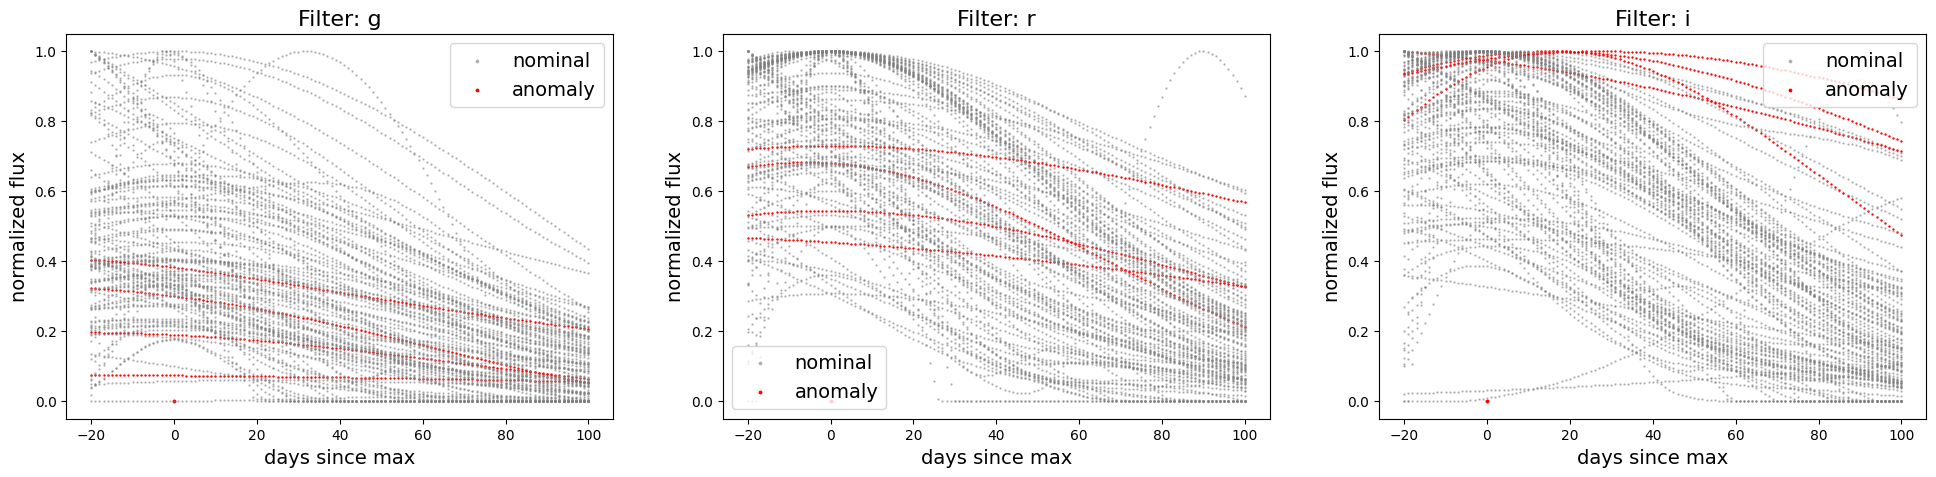

In [90]:
n_lc_plot = 100                     # number of light curves you want to see in this plot


end = 11                            # number of parameters from the GP-fit + bad fit epochs
done = []
leg_nominal = []
leg_anomaly = []

filters = ['g', 'r', 'i']          # LSST filters
n_days = 121                       # number of observed days per light curve


plt.figure(figsize=(24,5))

for i in range(n_lc_plot):
    indx = np.random.choice(np.arange(data.shape[0]))
    if indx not in done and min(data[indx][:-end]) >= 0:
        if metadata[indx] == 1:
            c = 'gray'
            alpha = 0.5
            name = 'nominal'
        elif metadata[indx] == -1:
            c = 'red'
            alpha=1
            name = 'anomaly'
        for j in range(1, 4):
            plt.subplot(1,3,j)
            plt.title('Filter: ' + filters[j-1] , fontsize=16)
            plt.scatter(np.arange(n_days)-20, data[indx][(j-1)*n_days:j*n_days], 
                        s=0.5, color=c, alpha=alpha)
            plt.xlabel('days since max', fontsize=14)
            plt.ylabel('normalized flux', fontsize=14)

            if name == 'anomaly' and j not in leg_anomaly:
                plt.scatter([0],[0], s=3, color=c, alpha=alpha, label=name)
                plt.legend(fontsize=14)
                leg_anomaly.append(j)
            elif name == 'nominal' and j not in leg_nominal:
                plt.scatter([0],[0], s=3, color=c, alpha=alpha, label=name)
                plt.legend(fontsize=14)
                leg_nominal.append(j)
        done.append(indx)

plt.show()

In [ ]:
The distribution of the 11 

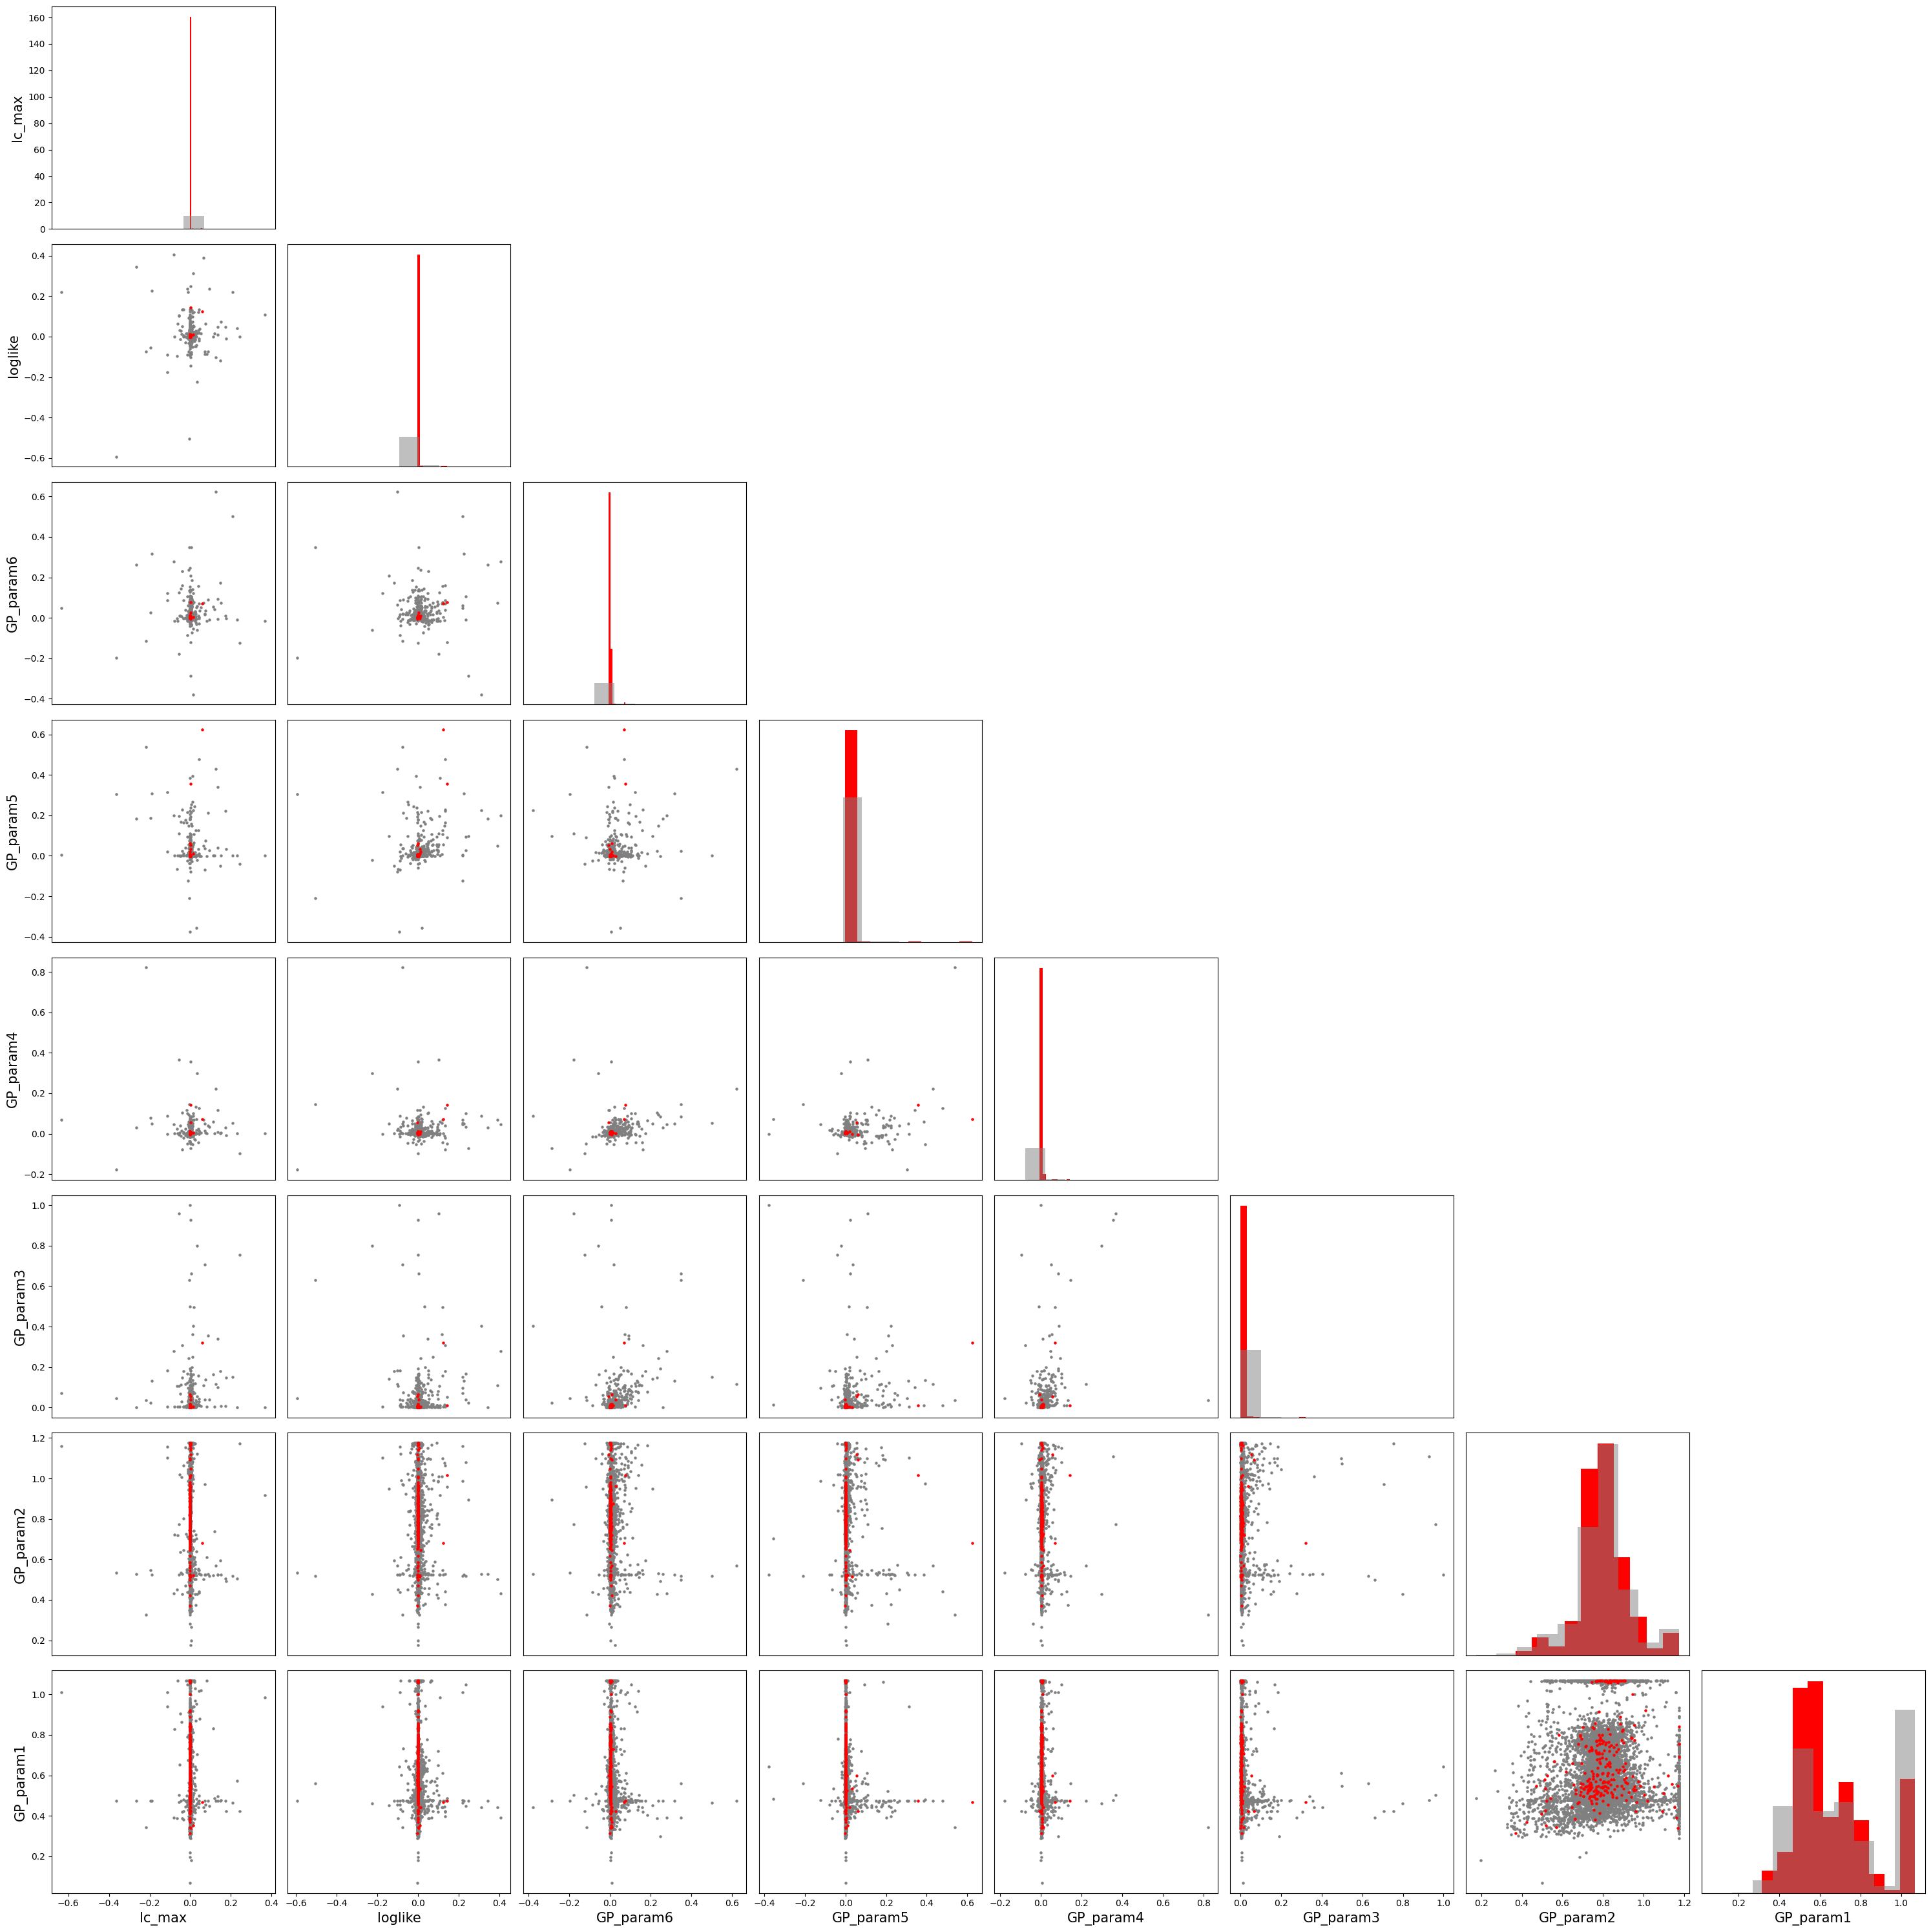

In [93]:
names = ['GP_param' + str(i) for i in range(1, 7)] + ['loglike', 'lc_max']

anomaly_mask = metadata == -1
anomaly_size = 5
nominal_size = 5

npanels = 8

plt.figure(figsize=(30,30))

for i in range(1, npanels + 1):
    for j in range(1, npanels + 1):
        if i > j:
            ax = plt.subplot(npanels,npanels,(i - 1)* npanels + j)
            plt.scatter(data[~anomaly_mask][:,-j], data[~anomaly_mask][:,-i], s=nominal_size, color='gray')
            plt.scatter(data[anomaly_mask][:,-j], data[anomaly_mask][:,-i], s=anomaly_size, color='red')

            if j == 1:
                plt.ylabel(names[-j - (i-1)], fontsize=15)
            else: 
                ax.yaxis.set_visible(False)

            if i == npanels:
                plt.xlabel(names[-j], fontsize=15)
            else:
                 ax.xaxis.set_visible(False)

        elif i == j:
            ax = plt.subplot(npanels,npanels,(i - 1)* npanels + j)
            plt.hist(data[anomaly_mask][:,-j], color='red', density=True)
            plt.hist(data[~anomaly_mask][:,-j], color='gray', alpha=0.5, density=True)

            if j == npanels:
                ax.yaxis.set_visible(False)
                plt.xlabel(names[-j], fontsize=15)
            elif j == 1:
                plt.ylabel(names[-j], fontsize=15)
                ax.xaxis.set_visible(False)
            else:
                ax.xaxis.set_visible(False)
                ax.yaxis.set_visible(False)
                
plt.tight_layout()
plt.show()